# PN-Junction Modulator



## General properties of semiconductors

In solids, electrons occupy _states_ that are characterized by a continuous vector parameter $\mathbf{k}$. The energy of these states, $\epsilon(\mathbf{k})$ arise as eigenvalues of the system's Hamiltonian and thus have some multiplicity. Roughly speaking, each continuous function $\epsilon_b(\mathbf{k})$ is called a _band_.

In semiconductors, the highest-energy occupied band and the lowest-energy empty (at zero temperature) band are approximately parabolic near the local maximum/minimum. This makes electrons subject to the crystal field behave like free charges with an effective mass given by the curvature of the bands. Therefore, electrical properties of bulk semicondutors can be approximated by the Drude model.

## Equilibrium concentrations

At thermal equilibrium, the number of electrons (per volume unit, $n$) in the conduction band (C) is given by the Fermi distribution,

$$ n = N_C \exp \left(-\frac{E_C  - E_F}{kT}\right). $$

Similarly, for hole density ($p$) in the valence band (V),
$$ p = N_V \exp \left(\frac{E_V  - E_F}{kT}\right). $$

Here, $N_C$ and $N_V$ are the effective density of states in each band and $E_C$ ($E_V$) is the  minimum (maximum) energy of the conduction (valence) band. Although these values depend of the temperature, their typical variation is small compared with the exponential and will be treated as constants.

### Intrinsic semiconductor

In intrinsic (undoped) semiconductors, the only source of free carriers is the creation of electron-hole pairs when electrons are promoted from the valence band,creating an equal number of holes $p = n$. This defines the intrinsic carrier density $n_i$ by
$$n_i^2 = {p ~ n}= {N_V N_C} \exp \left(-\frac{E_g}{kT}\right), $$
where $E_g = E_C-E_V$ is the _energy gap_ between bands, and the intrinsic Fermi level
$$ E_i =   \frac{E_V + E_C}{2} + \frac{kT}{2} \log \left(\frac{N_V}{N_C}\right)$$

### Extrinsic semiconductor

Dopants introduce new energy levels within the band gap, while changing the total number of electrons in the system: _donors_ add one extra electron per atom and create a donor level $E_D \lesssim E_C$, while _acceptors_ add one electron less while creaing an acceptor level $E_A \gtrsim E_V$. These levels lie so close to the original bands that, for practical purposes, impurities are considered to be fully ionized. I. e., the extra electrons from donors go to the conduction band and acceptors take one electron from the valence band, thus creating a hole.
Therefore, the **total charge density** for fully ionized impurities is
$$\rho = q (p - n + N_D - N_A)$$
where $N_D$ and $N_A$ are the donor and acceptor densities.

At equilibrium, neutrality implies $\rho = 0$ and mass action law forces $pn = n_i^2$, even when $p,n \neq n_i$. Let $C = N_D-N_A$, then the equilibrium carrier densities $n_0$, $p_0$ are given by
$$\frac{n_i^2}{n_0} - n_0 + C = 0 \Rightarrow n_0 = \frac{1}{2} \left( {\sqrt{C^2+4 n_i^2} + C}\right) $$
$$p_0 -\frac{n_i^2}{p_0} + C = 0 \Rightarrow p_0 = \frac{1}{2} \left( {\sqrt{C^2+4 n_i^2} - C}\right) $$

### Non-homogeneous semiconductor

If doping is not uniform, carrier gradients lead to diffusion currents, which break charge neutrality. An electrostatic potential $\phi$ builds up shifting energy bands accordingly, $\epsilon \to \epsilon - q \phi$. Fermi distributions can be rewritten with explicit position dependence as
$$ n(\mathbf{x}) = N_C \exp \left(-\frac{E_C - q \phi(\mathbf{x}) - E_F}{kT}\right), $$
$$ p(\mathbf{x}) = N_V \exp \left( \frac{E_V - q \phi(\mathbf{x}) - E_F}{kT}\right). $$
The potential then needs to be determined self-consistently so that it satisfies the Poisson equation (for uniform permmitivity $\varepsilon_s$),
$$ -\nabla^2 \phi = \frac{q}{\varepsilon_s}  (p - n + C),$$
with boundary conditions set assuming that equilibrium is restored far from the junction, i.e., $ n(\mathbf{x}) \to n_0(\infty)$, etc. Hence, at equilibrium, the built-in potential difference results
$$\Delta \phi_{0} = \frac{kT}{q} \log \left( \frac{p_0 (-\infty) n_0 (+\infty)}{n_i^2}  \right)$$

The equilibrium potential profile can be obtained by solving Poisson's equation in terms of $\psi = \frac{q\phi + E_F - E_i}{kT}$,
$$ \nabla^2 \psi = \frac{2\, n_i\, q^2}{\varepsilon_s\, k\, T} \left(\sinh (\psi) - \frac{C}{2\, n_i} \right).$$

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

In [ ]:
# PHYSICAL CONSTANTS @ 300 K
q = 1.602e-19           # (C)
eps_0 = 8.854e-14       # (F/cm)
eps_Si = 11.7 * eps_0   # (F/cm)
VT = 0.0259             # (V)

# TYPICAL SILICON PARAMETERS
ni = 1.6e10             # (cm^-3)
Dn = 1.00e3 * VT        # (cm^2/s)
Dp = 0.45e3 * VT        # (cm^2/s)
tau = 1e-6              # (s)

# GEOMETRY
L = 4e-4             # (cm)
a = 1e-6           # (cm)

# DOPING
NA = 2e16               # (cm^-3)
ND = 2e16               # (cm^-3)

def C_doping(x):
    step = 1.0/(1.0 + np.exp(-x/a))
    return -(NA * (1-step) - ND * step)

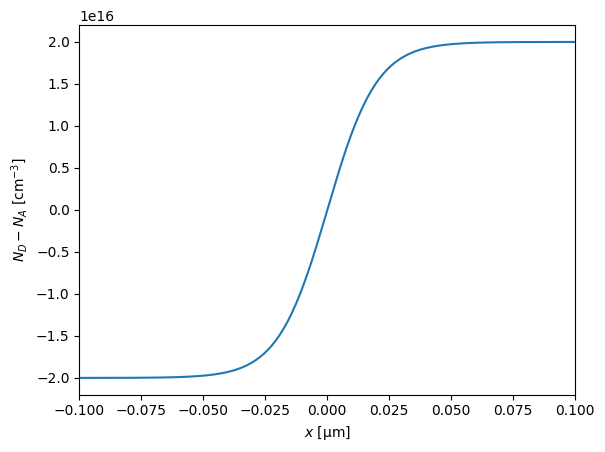

In [ ]:
# Plot of doping profile
x = np.linspace(-L/2,L/2,5001)
plt.plot(1e4*x, C_doping(x))
plt.xlim(1e5*(-a),1e5*a)
plt.xlabel("$x$ [μm]")
plt.ylabel("$N_D - N_A$ [cm$^{-3}$]");

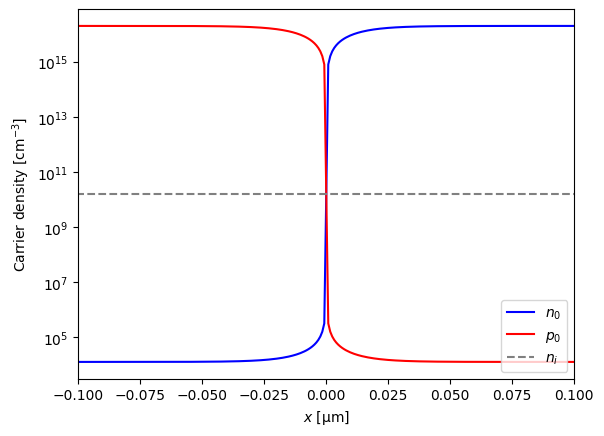

In [ ]:
# Local equilibrium carrier density
# n0 = p0 + ND - NA
# n0 * p0 = ni**2

C = C_doping(x)
p0 = (-C + np.sqrt(C**2 + 4*ni**2))/2
n0 = ( C + np.sqrt(C**2 + 4*ni**2))/2

plt.plot(1e4*x, n0, color="blue", label="$n_0$")
plt.plot(1e4*x, p0, color="red", label="$p_0$")
plt.hlines(y=ni, xmin=-1e4*L/2, xmax=1e4*L/2, label="$n_i$",
           color="gray", linestyle="--")
plt.legend(loc=4)
plt.xlim(1e5*(-a),1e5*a)
plt.yscale("log")
plt.xlabel("$x$ [μm]")
plt.ylabel("Carrier density [cm$^{-3}$]");

Built-in potential: 0.7272022828606586
K^2: 191067.73116260357
Convergence successful!


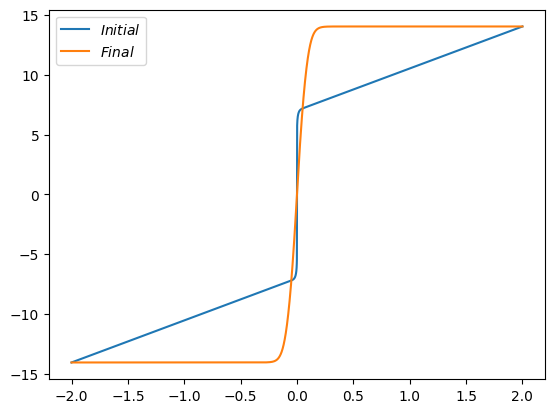

In [ ]:
# Built-in potential difference
phi_bi = VT * np.log(p0[0] * n0[-1] / ni**2)
print("Built-in potential:", phi_bi)

# Find potential profile
from scipy.integrate import solve_bvp
K2 = 2*ni*q/eps_Si/VT
print("K^2:", K2)

def ode_system(x, y):
      dydx = y[1]
      d2ydx2 = K2 * (np.sinh(y[0]) - C_doping(x)/(2*ni))
      return np.vstack((dydx, d2ydx2))

def boundary_conditions(ya, yb):
      # BC 1: y'(-L/2) = 0
      bc_left_deriv = ya[1]
      # BC 2: y'(L/2) = 0
      bc_right_deriv = yb[1]
      return np.array([bc_left_deriv, bc_right_deriv])

y_initial_guess = (np.asinh(C_doping(x)/(2*ni)) + phi_bi/VT * x/L)/2
dy_initial_guess = np.gradient(y_initial_guess, x)
y_guess = np.vstack((y_initial_guess, dy_initial_guess))

# Solve the BVP (with high node allocation for sharp gradients)
sol = solve_bvp(ode_system, boundary_conditions, x, y_guess, max_nodes=100000)
if sol.success:
    print("Convergence successful!")

psi = sol.sol(x)[0]

plt.plot(1e4*x, y_initial_guess, label=r"$Initial$")
plt.plot(1e4*x, psi, label=r"$Final$")
plt.legend()
plt.show()

In [ ]:
# Sze's approximation for abrupt junction

# n0 = ND, p0=NA
V_bi =VT * np.log(NA * ND / ni**2)
print("Built-in potential:", V_bi)

# xn * ND = xp * NA
# Vbi = q/eps (NA xp^2 + ND xn^2)/2
xn = np.sqrt(2*V_bi*eps_Si/q/(ND*(ND/NA +1)))
xp =-np.sqrt(2*V_bi*eps_Si/q/(NA*(NA/ND +1)))
print("Depletion region W =",-xp+xn)

E_max = q/eps_Si * NA * xp
E_Sze = np.interp(x, [-L/2,xp,0,xn,L/2],[0,0,E_max,0,0])
C_Sze = np.interp(x, [-L/2,xp,xp,0,0,xn,xn,L/2],[0,0,-NA,-NA,ND,ND,0,0])

Built-in potential: 0.7272022828606255
Depletion region W = 3.066719455775117e-05


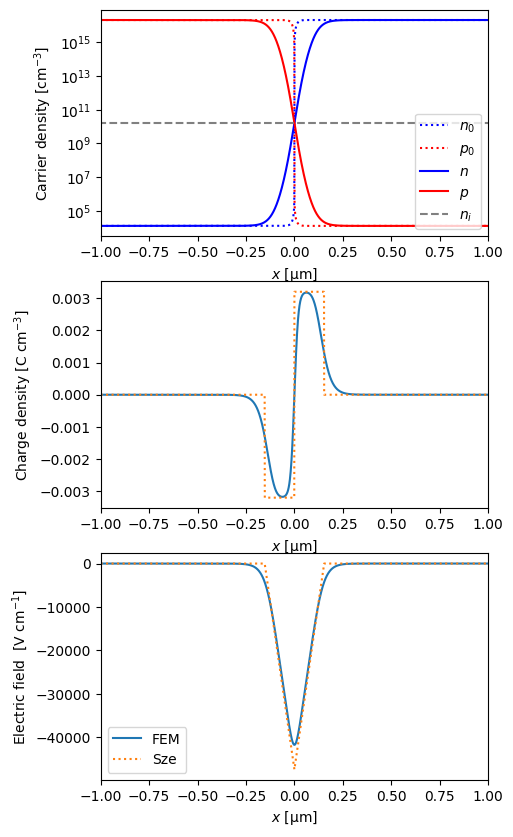

In [ ]:
psi_eq = sol.sol(x)[0]
dpsi_eq = sol.sol(x)[1]
n_eq = n0[-1] * np.exp(-(psi[-1] - psi))
p_eq = p0[0] * np.exp(-(psi - psi[0]))

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(5,10))
ax1.plot(1e4*x, n0, color="blue", label="$n_0$", linestyle=":")
ax1.plot(1e4*x, p0, color="red", label="$p_0$", linestyle=":")
ax1.plot(1e4*x, n_eq, color="blue", label="$n$")
ax1.plot(1e4*x, p_eq, color="red", label="$p$")
ax1.hlines(y=ni, xmin=-1e4*L/2, xmax=1e4*L/2, label="$n_i$",
           color="gray", linestyle="--")
ax1.legend(loc=4)
ax1.set_xlim(-1,1)
ax1.set_yscale("log")
ax1.set_xlabel("$x$ [μm]")
ax1.set_ylabel("Carrier density [cm$^{-3}$]");

# Charge density
def C_density(n,p):
    return q * (p - n + C)

ax2.plot(1e4*x, C_density(n_eq,p_eq))
ax2.plot(1e4*x, C_Sze*q, linestyle=":")
ax2.set_xlim(-1,1)
ax2.set_xlabel("$x$ [μm]")
ax2.set_ylabel("Charge density [C cm$^{-3}$]");

# Electric field
ax3.plot(1e4*x, -dpsi_eq*VT, label="FEM")
ax3.plot(1e4*x,E_Sze, linestyle=":", label="Sze")
ax3.set_xlabel("$x$ [μm]")
ax3.set_xlim(-1,1)
ax3.legend()
ax3.set_ylabel("Electric field  [V cm$^{-1}$]");

## Biased junction

When an external bias is applied the system is no longer at equilibrium. Although each carrier type can locally reach equilibrium densities, there is no longer a common Fermi level across the whole system. In the general case, solutions are often found by iterating through the following equations:

**Poisson's equation** for the electrostatic potential $\phi$:
$$\nabla \cdot (\epsilon_s \nabla \phi) = - \rho$$

**Drift-diffusion equation** using $\mathbf{E} = -\nabla \phi$
  - Electron particle current:
$$\mathbf{J}_n = \mu_n n \nabla \phi - D_n \nabla n$$
  - Hole particle current:
$$\mathbf{J}_p =-\mu_p p \nabla \phi - D_p \nabla p$$
with $D = \mu \, V_T, V_T = \frac{kT}{q}.$

**Generation-recombination rate** using simplified Shockley-Read-Hall model
$$R = \frac{np - n_i^2}{\tau (n+p+2 n_i)}$$

**Continuity equations**
  - Electron balance:
$$ \frac{\partial n}{\partial t} =  - \nabla \cdot \mathbf{J}_n - R$$
  - Hole balance:
$$ \frac{\partial p}{\partial t} =  - \nabla \cdot \mathbf{J}_p - R$$

For numerical reasons, better work with log-transformed densities:

**Definitions**
$$u_n = \log(n/n_i) \Rightarrow n = n_i \, \exp(u_n)$$
$$u_p = \log(p/n_i) \Rightarrow p = n_i \, \exp(u_p)$$

**Poisson's equation** for the adimensional electrostatic potential $\psi = \phi / V_T $:
$$\nabla^2 \psi = - \frac{q^2 \, n_i}{\epsilon_s \, k\, T} \left[ \exp(u_p) - \exp(u_n) + \frac{C}{n_i} \right]$$

**Current**
$${\mathbf{j}}_n = \frac{\mathbf{J}_n}{n \,D_n}= \nabla \left( \psi- u_n \right)$$

$${\mathbf{j}}_p = \frac{\mathbf{J}_p}{p \,D_p}= -\nabla \left(\psi + u_p \right)$$

**Recombination**
$$r_n =\frac{R}{n} = \frac{\exp(u_p) - \exp(-u_n) }
{\tau (\exp(u_n)+\exp(u_p)+2)}$$

$$r_p =\frac{R}{p} = \frac{\exp(u_n) - \exp(-u_p) }
{\tau (\exp(u_n)+\exp(u_p)+2)}$$

**Time derivatives**
$$\frac{\partial u_n}{\partial t} = \frac{1}{n} \frac{\partial n}{\partial t}$$

$$\frac{\partial u_p}{\partial t} = \frac{1}{p} \frac{\partial p}{\partial t}$$

## Steady state conditions

Assuming that bias changes are slow enough, time derivatives can be neglected.

In [ ]:
# Check consistency with equilibrium solution

V_bias = -0.001 # Finite bias needed or algorithm fails

y_guess = np.vstack((psi_eq+phi_bi/2/VT, np.log(n_eq/ni), np.log(p_eq/ni),
                    dpsi_eq, np.zeros(len(x)), np.zeros(len(x))))

def ode_system(x, y):
    # unpack variables from y:    psi = y[0]
    u_n = y[1]
    u_p = y[2]
    dpsi = y[3]
    J_n = y[4]
    J_p = y[5]
    # transform log-densities
    n = ni * np.exp(u_n)
    p = ni * np.exp(u_p)

    # Poisson equation
    d2psidx2 = -q/(eps_Si * VT) * (p - n + C_doping(x))

    # Currents
    du_n = -J_n/Dn/n + dpsi
    du_p = -J_p/Dp/p - dpsi

    # Recombination
    R = (n * p - ni**2) / (tau * (n + p + 2 * ni))

    return np.vstack((dpsi, du_n, du_p, d2psidx2, -R, -R))

def boundary_conditions(ya, yb):
      # Left (x=-L/2)
      psi_left_value = V_bias/VT
      un_left = np.log(n_eq[0]/ni)
      up_left = np.log(p_eq[0]/ni)

      # Right (x=L/2)
      psi_right_value = phi_bi/VT
      un_right = np.log(n_eq[-1]/ni)
      up_right = np.log(p_eq[-1]/ni)

      # Residuals
      res_array=[ya[0]-psi_left_value,
                 yb[0]-psi_right_value,
                 ya[1]-un_left,
                 yb[1]-un_right,
                 ya[2]-up_left,
                 yb[2]-up_right]

      return np.array(res_array)


# Solve the BVP (with high node allocation for sharp gradients)
sol = solve_bvp(ode_system, boundary_conditions, x, y_guess, max_nodes=1e6)
if sol.success:
    J_n = sol.sol(x)[4]
    J_p = sol.sol(x)[5]
    print("Convergence successful!")
    print(f"Current density: {q*np.mean(J_p-J_n):.3} A/cm².")
else:
    print("Convergence failed:")
    if(sol.status == 1):
        print("The maximum number of mesh nodes is exceeded.")
    if(sol.status == 2):
        print("A singular Jacobian encountered when solving the collocation system.")

Convergence successful!
Current density: -7.81e-11 A/cm².


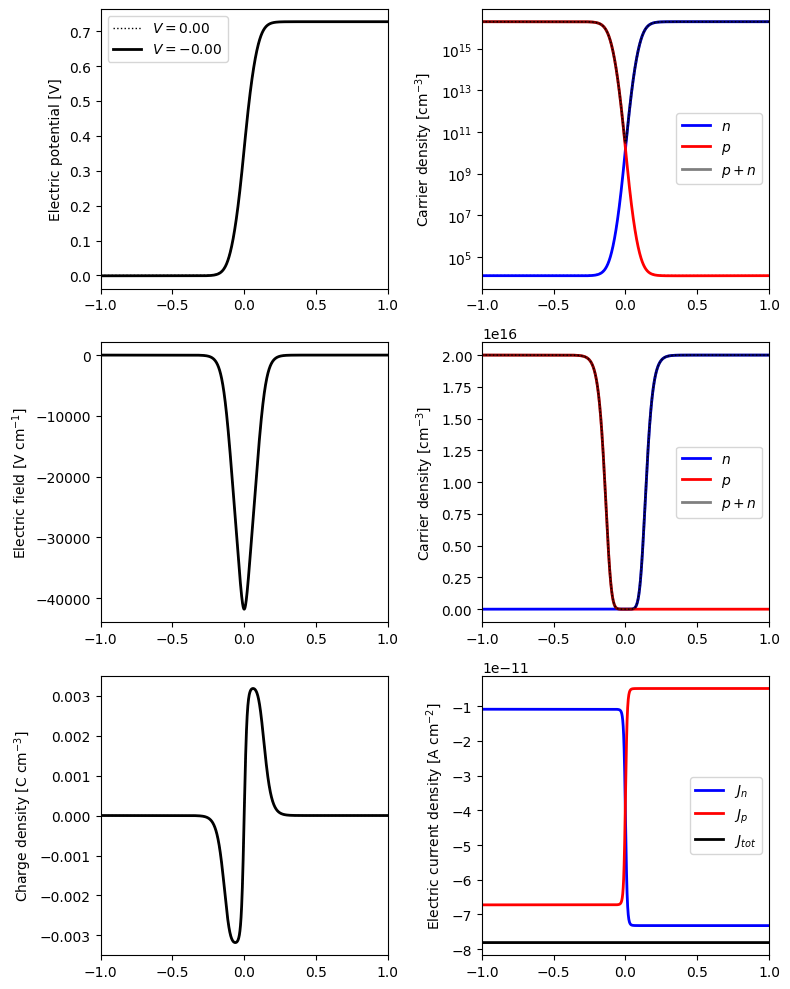

In [ ]:
# unpack variables from y:
psi = sol.sol(x)[0]
u_n = sol.sol(x)[1]
u_p = sol.sol(x)[2]
dpsi = sol.sol(x)[3]
n_bias = ni * np.exp(u_n)
p_bias = ni * np.exp(u_p)

fig,ax = plt.subplots(3,2,figsize=(8,10))

# Plot potential
ax[0][0].plot(1e4*x, VT*y_guess[0], color="black", linewidth=1, linestyle=":",label=f"$V={0.0:.02f}$")
ax[0][0].plot(1e4*x, VT*psi, color="black", linewidth=2, linestyle="-",label=f"$V={V_bias:.02f}$")
ax[0][0].set_xlim(-1,1)
ax[0][0].set_ylabel("Electric potential [V]")
ax[0][0].legend()

# Plot carrier density (log scale)
ax[0][1].plot(1e4*x, n_eq, color="blue", linewidth=1,linestyle=":")
ax[0][1].plot(1e4*x, n_bias, color="blue",linewidth=2, linestyle="-", label="$n$")
ax[0][1].plot(1e4*x, p_eq, color="red", linewidth=1,linestyle=":")
ax[0][1].plot(1e4*x, p_bias, color="red",linewidth=2, linestyle="-", label="$p$")
ax[0][1].plot(1e4*x, n_bias + p_bias, color="black", linewidth=2, linestyle="-", label="$p+n$", alpha = 0.5)
ax[0][1].plot(1e4*x, n_eq + p_eq, color="black", linewidth=1, linestyle=":")
ax[0][1].set_yscale("log")
ax[0][1].set_xlim(-1,1)
ax[0][1].set_ylabel("Carrier density [cm$^{-3}$]")
ax[0][1].legend()

# Plot carrier density (lin scale)
ax[1][1].plot(1e4*x, n_eq, color="blue", linewidth=1,linestyle=":")
ax[1][1].plot(1e4*x, n_bias, color="blue",linewidth=2, linestyle="-", label="$n$")
ax[1][1].plot(1e4*x, p_eq, color="red", linewidth=1,linestyle=":")
ax[1][1].plot(1e4*x, p_bias, color="red",linewidth=2, linestyle="-", label="$p$")
ax[1][1].plot(1e4*x, n_bias + p_bias, color="black", linewidth=2, linestyle="-", label="$p+n$", alpha = 0.5)
ax[1][1].plot(1e4*x, n_eq + p_eq, color="black", linewidth=1, linestyle=":")
ax[1][1].set_xlim(-1,1)
ax[1][1].set_ylabel("Carrier density [cm$^{-3}$]")
ax[1][1].legend()


# Plot electric field
ax[1][0].plot(1e4*x, -VT*y_guess[3], color="black", linewidth=1, linestyle=":")
ax[1][0].plot(1e4*x, -VT*dpsi, color="black", linewidth=2, linestyle="-")
ax[1][0].set_ylabel("Electric field [V cm$^{-1}$]")
ax[1][0].set_xlim(-1,1)

# Plot carrier currents
ax[2][1].plot(1e4*x, -q * J_n, color="blue",linewidth=2, linestyle="-", label="$J_n$")
ax[2][1].plot(1e4*x, q * J_p, color="red",linewidth=2, linestyle="-", label="$J_p$")
ax[2][1].plot(1e4*x, q * (J_p-J_n), color="black",linewidth=2, linestyle="-", label="$J_{tot}$")
ax[2][1].set_xlim(-1,1)
ax[2][1].set_ylabel("Electric current density [A cm$^{-2}$]")
ax[2][1].legend()

# Plot charge density
ax[2][0].plot(1e4*x, q*ni*(np.exp(y_guess[2])-np.exp(y_guess[1])+C/ni), color="black", linewidth=1, linestyle=":")
ax[2][0].plot(1e4*x, q*ni*(np.exp(u_p)-np.exp(u_n)+C/ni), color="black", linewidth=2, linestyle="-")
ax[2][0].set_xlim(-1,1)
ax[2][0].set_ylabel("Charge density [C cm$^{-3}$]")


fig.tight_layout()
fig.show()

In [ ]:
# Test reverse bias

V_bias = -0.25

# Sze's approximation for abrupt junction

# n0 = ND, p0=NA
V_tot = V_bi - V_bias

# xn * ND = xp * NA
# Vbi = q/eps (NA xp^2 + ND xn^2)/2
xn = np.sqrt(2*V_tot*eps_Si/q/(ND*(ND/NA +1)))
xp =-np.sqrt(2*V_tot*eps_Si/q/(NA*(NA/ND +1)))
print("Depletion region W =",-xp+xn)

E_max = q/eps_Si * NA * xp
E_Sze = np.interp(x, [-L/2,xp,0,xn,L/2],[0,0,E_max,0,0])
C_Sze = np.interp(x, [-L/2,xp,xp,0,0,xn,xn,L/2],[0,0,-NA,-NA,ND,ND,0,0])


y_guess = np.vstack((psi_eq+phi_bi/2/VT, np.log(n_eq/ni), np.log(p_eq/ni),
                    dpsi_eq, np.zeros(len(x)), np.zeros(len(x))))

def ode_system(x, y):
    # unpack variables from y:    psi = y[0]
    u_n = y[1]
    u_p = y[2]
    dpsi = y[3]
    J_n = y[4]
    J_p = y[5]
    # transform log-densities
    n = ni * np.exp(u_n)
    p = ni * np.exp(u_p)

    # Poisson equation
    d2psidx2 = -q/(eps_Si * VT) * (p - n + C_doping(x))

    # Currents
    du_n = -J_n/Dn/n + dpsi
    du_p = -J_p/Dp/p - dpsi

    # Recombination
    R = (n * p - ni**2) / (tau * (n + p + 2 * ni))

    return np.vstack((dpsi, du_n, du_p, d2psidx2, -R, -R))

def boundary_conditions(ya, yb):
      # Left (x=-L/2)
      psi_left_value = V_bias/VT
      un_left = np.log(n_eq[0]/ni)
      up_left = np.log(p_eq[0]/ni)

      # Right (x=L/2)
      psi_right_value = phi_bi/VT
      un_right = np.log(n_eq[-1]/ni)
      up_right = np.log(p_eq[-1]/ni)

      # Residuals
      res_array=[ya[0]-psi_left_value,
                 yb[0]-psi_right_value,
                 ya[1]-un_left,
                 yb[1]-un_right,
                 ya[2]-up_left,
                 yb[2]-up_right]

      return np.array(res_array)


# Solve the BVP (with high node allocation for sharp gradients)
sol = solve_bvp(ode_system, boundary_conditions, x, y_guess, max_nodes=1e6)
if sol.success:
  # unpack variables from y:
  psi = sol.sol(x)[0]
  u_n = sol.sol(x)[1]
  u_p = sol.sol(x)[2]
  dpsi = sol.sol(x)[3]
  n_bias = ni * np.exp(u_n)
  p_bias = ni * np.exp(u_p)
  J_n = sol.sol(x)[4]
  J_p = sol.sol(x)[5]

  print("Convergence successful!")
  print(f"Current density: {q*np.mean(J_p-J_n):.3} A/cm².")

  fig,ax = plt.subplots(3,2,figsize=(8,10))

  # Plot potential
  ax[0][0].plot(1e4*x, VT*y_guess[0], color="black", linewidth=1, linestyle=":",label=f"$V={0.0:.02f}$")
  ax[0][0].plot(1e4*x, VT*psi, color="black", linewidth=2, linestyle="-",label=f"$V={V_bias:.02f}$")
  ax[0][0].set_xlim(-1,1)
  ax[0][0].set_ylabel("Electric potential [V]")
  ax[0][0].legend()

  # Plot carrier density (log scale)
  ax[0][1].plot(1e4*x, n_eq, color="blue", linewidth=1,linestyle=":")
  ax[0][1].plot(1e4*x, n_bias, color="blue",linewidth=2, linestyle="-", label="$n$")
  ax[0][1].plot(1e4*x, p_eq, color="red", linewidth=1,linestyle=":")
  ax[0][1].plot(1e4*x, p_bias, color="red",linewidth=2, linestyle="-", label="$p$")
  ax[0][1].plot(1e4*x, n_bias + p_bias, color="black", linewidth=2, linestyle="-", label="$p+n$", alpha = 0.5)
  ax[0][1].plot(1e4*x, n_eq + p_eq, color="black", linewidth=1, linestyle=":")
  ax[0][1].set_yscale("log")
  ax[0][1].set_xlim(-1,1)
  ax[0][1].set_ylabel("Carrier density [cm$^{-3}$]")
  ax[0][1].legend()

  # Plot carrier density (lin scale)
  ax[1][1].plot(1e4*x, n_eq, color="blue", linewidth=1,linestyle=":")
  ax[1][1].plot(1e4*x, n_bias, color="blue",linewidth=2, linestyle="-", label="$n$")
  ax[1][1].plot(1e4*x, p_eq, color="red", linewidth=1,linestyle=":")
  ax[1][1].plot(1e4*x, p_bias, color="red",linewidth=2, linestyle="-", label="$p$")
  ax[1][1].plot(1e4*x, n_bias + p_bias, color="black", linewidth=2, linestyle="-", label="$p+n$", alpha = 0.5)
  ax[1][1].plot(1e4*x, n_eq + p_eq, color="black", linewidth=1, linestyle=":")
  ax[1][1].set_xlim(-1,1)
  ax[1][1].set_ylabel("Carrier density [cm$^{-3}$]")
  ax[1][1].legend()

  # Plot electric field
  ax[1][0].plot(1e4*x, -VT*y_guess[3], color="black", linewidth=1, linestyle=":")
  ax[1][0].plot(1e4*x, -VT*dpsi, color="black", linewidth=2, linestyle="-", label="solver")
  ax[1][0].plot(1e4*x, E_Sze, color="orange", linestyle="--", label="Sze")
  ax[1][0].set_ylabel("Electric field [V cm$^{-1}$]")
  ax[1][0].set_xlim(-1,1)
  ax[1][0].legend()

  # Plot carrier currents
  ax[2][1].plot(1e4*x, -q * J_n, color="blue",linewidth=2, linestyle="-", label="$J_n$")
  ax[2][1].plot(1e4*x, q * J_p, color="red",linewidth=2, linestyle="-", label="$J_p$")
  ax[2][1].plot(1e4*x, q * (J_p-J_n), color="black",linewidth=2, linestyle="-", label="$J_{tot}$")
  ax[2][1].set_xlim(-1,1)
  ax[2][1].set_ylabel("Electric current density [A cm$^{-2}$]")
  ax[2][1].legend()

  # Plot charge density
  ax[2][0].plot(1e4*x, q*ni*(np.exp(y_guess[2])-np.exp(y_guess[1])+C/ni), color="black", linewidth=1, linestyle=":")
  ax[2][0].plot(1e4*x, q*ni*(np.exp(u_p)-np.exp(u_n)+C/ni), color="black", linewidth=2, linestyle="-")
  ax[2][0].plot(1e4*x, q*C_Sze, color="orange", linestyle="--")
  ax[2][0].set_xlim(-1,1)
  ax[2][0].set_ylabel("Charge density [C cm$^{-3}$]")

  fig.tight_layout()
  fig.show()

else:
  print("Convergence failed:")
  if(sol.status == 1):
      print("The maximum number of mesh nodes is exceeded.")
  if(sol.status == 2):
      print("A singular Jacobian encountered when solving the collocation system.")

Depletion region W = 3.554992330177471e-05
Convergence failed:
The maximum number of mesh nodes is exceeded.


In [ ]:
# Reverse voltage sweep
y_guess = np.vstack((psi_eq+phi_bi/2/VT, np.log(n_eq/ni), np.log(p_eq/ni),
                    dpsi_eq, np.zeros(len(x)), np.zeros(len(x))))

biases = []
solutions = []

for rev_bias in np.linspace(0.1,3.5,35):
  V_bias = -rev_bias
  print("Solving for V_bias =",V_bias)
  def ode_system(x, y):
    # unpack variables from y:
    psi = y[0]
    u_n = y[1]
    u_p = y[2]
    dpsi = y[3]
    J_n = y[4]
    J_p = y[5]
    # transform log-densities
    n = ni * np.exp(u_n)
    p = ni * np.exp(u_p)

    # Poisson equation
    d2psidx2 = -q/(eps_Si * VT) * (p - n + C_doping(x))

    # Currents
    du_n = -J_n/Dn/n + dpsi
    du_p = -J_p/Dp/p - dpsi

    # Recombination
    R = (n * p - ni**2) / (tau * (n + p + 2 * ni))

    return np.vstack((dpsi, du_n, du_p, d2psidx2, -R, -R))

  def boundary_conditions(ya, yb):
        # Left (x=-L/2)
        psi_left_value = V_bias/VT
        un_left = np.log(n_eq[0]/ni)
        up_left = np.log(p_eq[0]/ni)

        # Right (x=L/2)
        psi_right_value = phi_bi/VT
        un_right = np.log(n_eq[-1]/ni)
        up_right = np.log(p_eq[-1]/ni)

        # Residuals
        res_array=[ya[0]-psi_left_value,
                  yb[0]-psi_right_value,
                  ya[1]-un_left,
                  yb[1]-un_right,
                  ya[2]-up_left,
                  yb[2]-up_right]

        return np.array(res_array)

  # Solve the BVP (with high node allocation for sharp gradients)
  sol = solve_bvp(ode_system, boundary_conditions, x, y_guess, max_nodes=1e6)
  if sol.success:
    solution = sol.sol(x)
    biases.append(V_bias)
    solutions.append(solution)
    y_guess = solution
    print(f"Current density: {q*np.mean(solution[5]-solution[4]):.3} A/cm².")
  else:
    print("Convergence failed:")
    if(sol.status == 1):
        print("The maximum number of mesh nodes is exceeded.")
    if(sol.status == 2):
        print("A singular Jacobian encountered when solving the collocation system.")


Solving for V_bias = -0.1
Current density: -4.35e-09 A/cm².
Solving for V_bias = -0.2
Current density: -7e-09 A/cm².
Solving for V_bias = -0.3
Current density: -9.41e-09 A/cm².
Solving for V_bias = -0.4
Current density: -1.17e-08 A/cm².
Solving for V_bias = -0.5
Current density: -1.39e-08 A/cm².
Solving for V_bias = -0.6
Current density: -1.59e-08 A/cm².
Solving for V_bias = -0.7
Current density: -1.79e-08 A/cm².
Solving for V_bias = -0.7999999999999999
Current density: -1.99e-08 A/cm².
Solving for V_bias = -0.8999999999999999
Current density: -2.17e-08 A/cm².
Solving for V_bias = -0.9999999999999999
Current density: -2.35e-08 A/cm².
Solving for V_bias = -1.0999999999999999
Current density: -2.53e-08 A/cm².
Solving for V_bias = -1.2
Current density: -2.7e-08 A/cm².
Solving for V_bias = -1.3
Current density: -2.86e-08 A/cm².
Solving for V_bias = -1.4
Current density: -3.02e-08 A/cm².
Solving for V_bias = -1.5
Current density: -3.18e-08 A/cm².
Solving for V_bias = -1.5999999999999999
Cur

In [ ]:
# Forward voltage sweep

y_guess = np.vstack((psi_eq+phi_bi/2/VT, np.log(n_eq/ni), np.log(p_eq/ni),
                    dpsi_eq, np.zeros(len(x)), np.zeros(len(x))))

for for_bias in np.linspace(0.01,0.25,25):
  V_bias = for_bias
  print("Solving for V_bias =",V_bias)
  def ode_system(x, y):
    # unpack variables from y:
    psi = y[0]
    u_n = y[1]
    u_p = y[2]
    dpsi = y[3]
    J_n = y[4]
    J_p = y[5]
    # transform log-densities
    n = ni * np.exp(u_n)
    p = ni * np.exp(u_p)

    # Poisson equation
    d2psidx2 = -q/(eps_Si * VT) * (p - n + C_doping(x))

    # Currents
    du_n = -J_n/Dn/n + dpsi
    du_p = -J_p/Dp/p - dpsi

    # Recombination
    R = (n * p - ni**2) / (tau * (n + p + 2 * ni))

    return np.vstack((dpsi, du_n, du_p, d2psidx2, -R, -R))

  def boundary_conditions(ya, yb):
        # Left (x=-L/2)
        psi_left_value = V_bias/VT
        un_left = np.log(n_eq[0]/ni)
        up_left = np.log(p_eq[0]/ni)

        # Right (x=L/2)
        psi_right_value = phi_bi/VT
        un_right = np.log(n_eq[-1]/ni)
        up_right = np.log(p_eq[-1]/ni)

        # Residuals
        res_array=[ya[0]-psi_left_value,
                  yb[0]-psi_right_value,
                  ya[1]-un_left,
                  yb[1]-un_right,
                  ya[2]-up_left,
                  yb[2]-up_right]

        return np.array(res_array)

  # Solve the BVP (with high node allocation for sharp gradients)
  sol = solve_bvp(ode_system, boundary_conditions, x, y_guess, max_nodes=1e6)
  if sol.success:
    solution = sol.sol(x)
    biases.append(V_bias)
    solutions.append(solution)
    y_guess = solution
    print(f"Current density: {q*np.mean(solution[5]-solution[4]):.3} A/cm².")
  else:
    print("Convergence failed:")
    if(sol.status == 1):
        print("The maximum number of mesh nodes is exceeded.")
    if(sol.status == 2):
        print("A singular Jacobian encountered when solving the collocation system.")


Solving for V_bias = 0.01
Current density: 8.73e-10 A/cm².
Solving for V_bias = 0.02
Current density: 1.95e-09 A/cm².
Solving for V_bias = 0.03
Current density: 3.31e-09 A/cm².
Solving for V_bias = 0.04
Current density: 5.05e-09 A/cm².
Solving for V_bias = 0.05
Current density: 7.3e-09 A/cm².
Solving for V_bias = 0.060000000000000005
Current density: 1.03e-08 A/cm².
Solving for V_bias = 0.06999999999999999
Current density: 1.42e-08 A/cm².
Solving for V_bias = 0.08
Current density: 1.95e-08 A/cm².
Solving for V_bias = 0.09
Current density: 2.67e-08 A/cm².
Solving for V_bias = 0.09999999999999999
Current density: 3.65e-08 A/cm².
Solving for V_bias = 0.11
Current density: 5.01e-08 A/cm².
Solving for V_bias = 0.12
Current density: 6.9e-08 A/cm².
Solving for V_bias = 0.13
Current density: 9.55e-08 A/cm².
Solving for V_bias = 0.14
Current density: 1.33e-07 A/cm².
Solving for V_bias = 0.15000000000000002
Current density: 1.86e-07 A/cm².
Solving for V_bias = 0.16
Current density: 2.62e-07 A/cm

In [ ]:
# Add equilibrium condition and sort by bias
biases.append(0.0)
solutions.append(np.vstack((psi_eq+phi_bi/2/VT, np.log(n_eq/ni), np.log(p_eq/ni),
                            dpsi_eq, np.zeros(len(x)), np.zeros(len(x)))))
sol_order = np.argsort(biases)
biases = np.array(biases)[sol_order]
solutions = np.array(solutions)[sol_order]

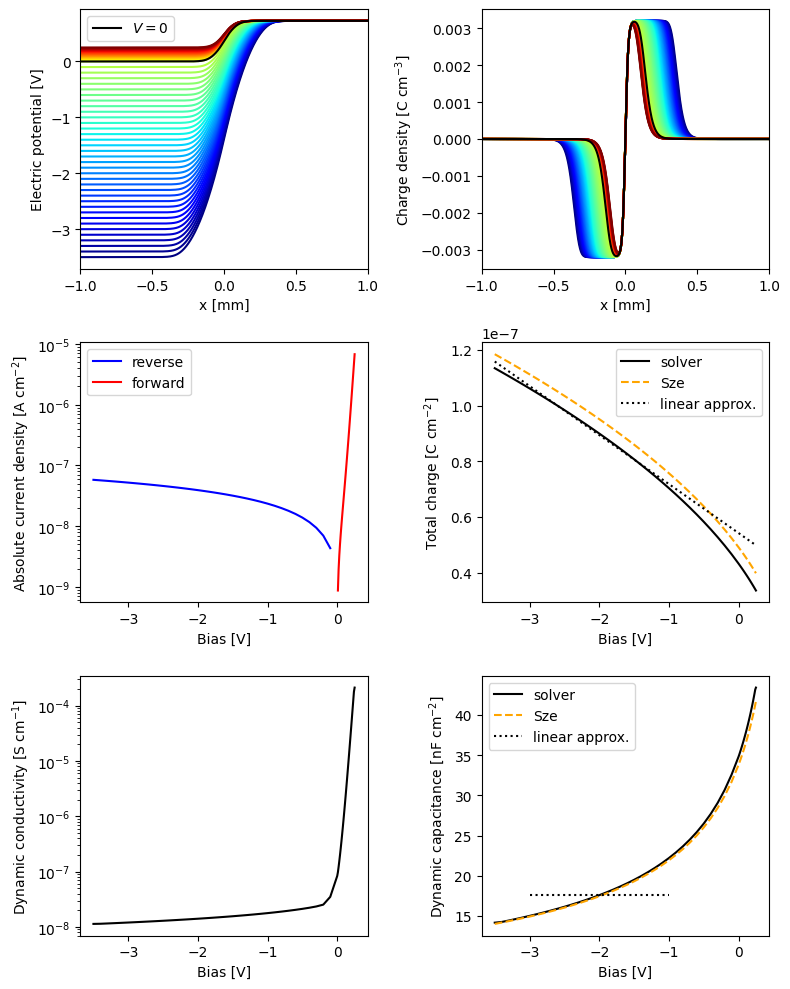

In [ ]:
n = len(solutions)
Q_tot = []

colors = plt.cm.jet(np.linspace(0,1,n))
fig,ax = plt.subplots(3,2,figsize=(8,10))

for i in range(n):
  solution = solutions[i]
  phi = VT * solution[0]
  c_tot = q * (ni *(np.exp(solution[2]) - np.exp(solution[1])) + C)
  Q_tot.append(np.trapezoid(np.abs(c_tot),x)/2)
  ax[0][0].plot(1e4*x, phi, color=colors[i])
  ax[0][1].plot(1e4*x, c_tot, color=colors[i])

ax[0][0].plot(1e4*x, VT * psi_eq+phi_bi/2, color = "black", label="$V=0$")
ax[0][1].plot(1e4*x, q * (p_eq-n_eq+C), color = "black")

ax[0][0].set_xlabel("x [mm]")
ax[0][0].set_ylabel("Electric potential [V]")
ax[0][0].set_xlim(-1,1)
ax[0][1].set_xlabel("x [mm]")
ax[0][1].set_ylabel("Charge density [C cm$^{-3}$]")
ax[0][1].set_xlim(-1,1)
ax[0][0].legend()

Q_tot = np.array(Q_tot)
J_tot = q * np.array([np.mean(sol[5]-sol[4]) for sol in solutions])
V_bias = np.array(biases)

ax[1][0].plot(V_bias[V_bias < 0], np.abs(J_tot[V_bias < 0]), color="blue", label="reverse")
ax[1][0].plot(V_bias[V_bias > 0], np.abs(J_tot[V_bias > 0]), color="red", label="forward")
ax[1][0].set_xlabel("Bias [V]")
ax[1][0].set_ylabel("Absolute current density [A cm$^{-2}$]")
ax[1][0].set_yscale("log")
ax[1][0].legend()

ax[1][1].plot(V_bias, Q_tot, color="black", label="solver")
ax[1][1].set_xlabel("Bias [V]")
ax[1][1].set_ylabel("Total charge [C cm$^{-2}$]")

ax[2][0].plot(V_bias, np.gradient(J_tot,V_bias)  , color="black")
ax[2][0].set_xlabel("Bias [V]")
ax[2][0].set_ylabel("Dynamic conductivity [S cm$^{-1}$]")
ax[2][0].set_yscale("log")

ax[2][1].plot(V_bias, 1e9* np.gradient(-Q_tot,V_bias)  , color="black", label="solver")
ax[2][1].set_xlabel("Bias [V]")
ax[2][1].set_ylabel("Dynamic capacitance [nF cm$^{-2}$]")
# Sze's approximation for abrupt junction
xn = np.array([np.sqrt(2*V_tot*eps_Si/q/(ND*(ND/NA +1))) for V_tot in (V_bi - V_bias)])
xp = np.array([np.sqrt(2*V_tot*eps_Si/q/(NA*(NA/ND +1))) for V_tot in (V_bi - V_bias)])
W = xn + xp
ax[1][1].plot(V_bias, q * ND * xn, color="orange", linestyle="--", label="Sze")
ax[2][1].plot(V_bias, 1e9* eps_Si/W, color="orange", linestyle="--", label="Sze")
# Average capacitance for +/- 1 V swing around -2 V bias
C_eff, Q_0 = np.polyfit(V_bias[(V_bias >= -3) & (V_bias <= -1)], Q_tot[(V_bias >= -3) & (V_bias <= -1)], deg=1)
ax[1][1].plot(V_bias, Q_0 + C_eff * V_bias, color="black", linestyle=":", label="linear approx.")
ax[2][1].hlines(-1e9 * C_eff, -3,-1, color="black", linestyle=":", label="linear approx.")
ax[1][1].legend()
ax[2][1].legend()

fig.tight_layout()
fig.show()

fig.tight_layout()
fig.show()

## Optical properties

Silicon photonics operates primarily across the Near-Infrared (NIR) and Mid-Infrared (Mid-IR) spectra, spanning from 1.1 μm up to approximately 8.5 μm. The most prominent wavelengths used in fiber-optic telecommunications, data centers, and optical interconnects are 1310 nm (O-band) and 1550 nm (C-band).

In a typical dielectric medium the overall susceptibility arises from the superposition of contributions from multiple resonances  corresponding to different transitions, $E_k = h \nu_k$. Below the resonance ($\nu \ll \nu_k$), only the real susceptibility contributes to the the refractive index and the it can be expanded as a sum over the various resonances, known as Sellmeier equation,
$$n^2=1 + \chi' = 1 + \sum_k \frac{\chi_k}{1-(\lambda_k/\lambda)^2},$$
with $\lambda_k = c/\nu_k.$


In [ ]:
# Refractive and extinction coefficient index of crystalline silicon at 300 K
# Ref. D. Franta et al., Appl. Surf. Sci. 421, 405-419 (2017)
# Available from https://refractiveindex.info/?shelf=main&book=Si&page=Franta-300K
from pathlib import Path
import urllib.request
csv_path = Path("Franta-300K.csv")
if not csv_path.exists():
    urllib.request.urlretrieve(
        "https://refractiveindex.info/tmp/database/data/main/Si/nk/Franta-300K.csv",
        csv_path)
wl, n = np.loadtxt(csv_path, delimiter=",", skiprows=1, usecols=(0,1), unpack=True, max_rows=4001)
wl, k = np.loadtxt(csv_path, delimiter=",", skiprows=4004, usecols=(0,1), unpack=True, max_rows=4001)

--2026-09-08 13:41:39--  https://refractiveindex.info/tmp/database/data/main/Si/nk/Franta-300K.csv
Resolving refractiveindex.info (refractiveindex.info)... 50.63.7.197
Connecting to refractiveindex.info (refractiveindex.info)|50.63.7.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 198843 (194K) [text/csv]
Saving to: ‘Franta-300K.csv’

Franta-300K.csv     100%[===================>] 194.18K  1.09MB/s    in 0.2s    

2026-09-08 13:41:40 (1.09 MB/s) - ‘Franta-300K.csv’ saved [198843/198843]



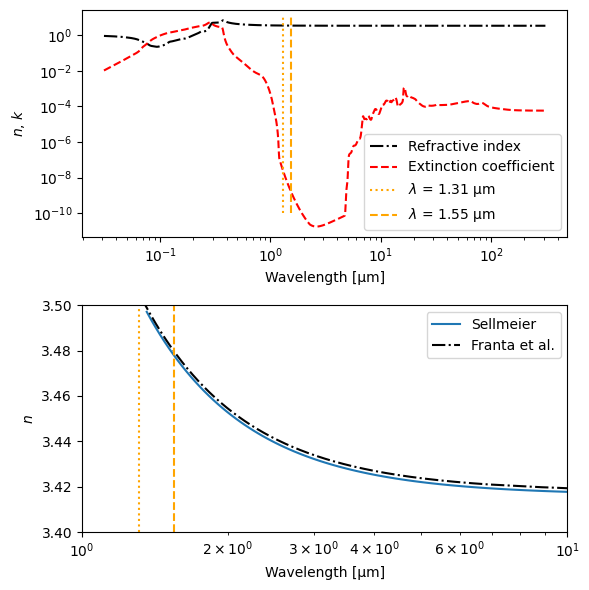

In [ ]:
# Sellmeier equations for silicon in the range 1.36-11 µm
# from Fundamentals of Photonics

lambda_k = np.array([0.3015, 1.1347, 1104.0])
chi1_k = np.array([10.6684,0.0030, 1.5413])

lambda_rng = np.logspace(np.log10(1.36),np.log10(11),100)
chi1 = np.array([np.sum(chi1_k/(1-(lambda_k/l)**2)) for l in lambda_rng])

fig, axs = plt.subplots(2,1,figsize=(6,6))
axs[0].plot(wl, n, '-.', color='black',  label="Refractive index")
axs[0].plot(wl, k, '--', color='red',  label="Extinction coefficient")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlabel("Wavelength [μm]")
axs[0].set_ylabel(r"$n$, $k$")
axs[0].vlines([1.31],ymin=1e-10,ymax=10, color='orange',
              linestyle=[':'], label = r"$\lambda$ = 1.31 µm")
axs[0].vlines([1.55],ymin=1e-10,ymax=10, color='orange',
              linestyle=['--'], label = r"$\lambda$ = 1.55 µm")
axs[0].legend()

axs[1].plot(lambda_rng, np.sqrt(1+chi1), label="Sellmeier")
axs[1].plot(wl, n, '-.', color='black',  label="Franta et al.")
axs[1].set_xscale("log")
axs[1].set_xlabel("Wavelength [μm]")
axs[1].set_xlim(1,10)
axs[1].set_ylim(3.4,3.5)
axs[1].set_ylabel(r"$n$")
axs[1].vlines([1.31,1.55],ymin=3.4,ymax=3.5, color='orange',
              linestyle=[':','--'])
axs[1].legend()

fig.tight_layout()
fig.show()

In [ ]:
print("Tabulated permittivity used before:", eps_Si)
print("Values from Sellmeier equations:")
eps_rf = np.sum(chi1_k/(1-(lambda_k/np.inf)**2)) * eps_0
eps_opt = np.sum(chi1_k/(1-(lambda_k/1.55)**2)) * eps_0
print("\t-permittivity at RF (out of valid range):", eps_rf)
print("\t-permittivity in the 1550 nm band:", eps_opt)
print("Values from  Franta et al.:")
eps_rf = (n[-1]**2 - 1) * eps_0
eps_opt = (np.interp(1.55,wl,n)**2 - 1) * eps_0
print(f"\t-permittivity at RF (max. {wl[-1]} µm):", eps_rf)
print("\t-permittivity in the 1550 nm band:", eps_opt)

Tabulated permittivity used before: 1.035918e-12
Values from Sellmeier equations:
	-permittivity at RF (out of valid range): 1.081312458e-12
	-permittivity in the 1550 nm band: 9.822972930635956e-13
Values from  Franta et al.:
	-permittivity at RF (max. 309.963 µm): 9.460689675885696e-13
	-permittivity in the 1550 nm band: 9.834214252151187e-13



In (linear) conductive materials, the combination of the dielectric and conductive properties can be represented by a complex frequency-dependent effective permittivity
$$  \varepsilon_{eff} = \varepsilon  + \frac{\sigma}{j\,\omega},$$
where $\sigma$ can be obtained from the Drude–Sommerfeld model,
$$\sigma(\omega) = \frac{n q^2 \tau}{m} \frac{1}{1 + j\omega \tau}.$$

In doped semiconductors, electrons and holes are modeled as carriers with effective mass $m^*$ ([ref](https://www.ioffe.ru/SVA/NSM/Semicond/Si/bandstr.html#Masses))
- $m_{ce}^{*}= 0.26 \cdot m_0$
- $m_{ch}^{*}= 0.38 \cdot m_0$

each contributing to the total conuctivity
$$\sigma(\omega) = \sigma_n(\omega)  + \sigma_p(\omega), $$
with
$$\sigma_n(\omega) = \frac{n\,q\,\mu_n}{1 + j\omega \tau_e},$$

$$\sigma_p(\omega) = \frac{p\,q\,\mu_p}{1 + j\omega \tau_h}.$$

Relaxation times can be retrieved from the mobility $\mu = q \tau /m^*$. As the impurity concentration $N_I$ increases (at room temperature most impurities are ionized) the mobility decreases. For $N_I = 2 \times 10^{16}$ cm$^{-3}$ (Sze),


In [ ]:
# Carrier mobility
mu_n = 1000e-4 # m²/(V s)
mu_p = 450e-4 # m²/(V s)

# Effective mass
m0 = 9.11e-31 # kg
m_ce = 0.26 * m0
m_ch = 0.38 * m0

# Relaxation times
tau_e = m_ce * mu_n /q
tau_h = m_ch * mu_p /q

# Frequency for 1550 nm band
c = 299792458 # m/s
lambda_opt = 1.55e-6 # m
w_opt = 2 * np.pi * c/lambda_opt

print("ω τ_e =", w_opt * tau_e)
print("ω τ_h =", w_opt * tau_h)

ω τ_e = 179.67931627110266
ω τ_h = 118.17370416291749


For optical frequencies (in the *relaxation regime*), $\omega \, \tau_{e,h} \gg 1$, so
$$\Re(  \varepsilon_{eff}) \simeq \varepsilon  \left(1 - \frac{\omega^2_{\mathcal{P},e}}{\omega^2} - \frac{\omega^2_{\mathcal{P},h}}{\omega^2}\right),$$
$$\Im(  \varepsilon_{eff}) \simeq \varepsilon  \left(\frac{\omega^2_{\mathcal{P},e}}{\omega^3 \tau_e} + \frac{\omega^2_{\mathcal{P},h}}{\omega^3 \tau_h}\right),$$

where the plasma frequencies are given by

$$  \omega^2_{\mathcal{P},e} =  \frac{n\,q\,\mu_n}{\tau_e \, \varepsilon} \qquad  \omega^2_{\mathcal{P},h} = \frac{p\,q\,\mu_p }{\tau_h \, \varepsilon }.$$

Then, refractive index and extinction coefficient can be obtained from the equation
$$n + jk = \sqrt{\varepsilon_{eff} / \varepsilon_{0}} $$

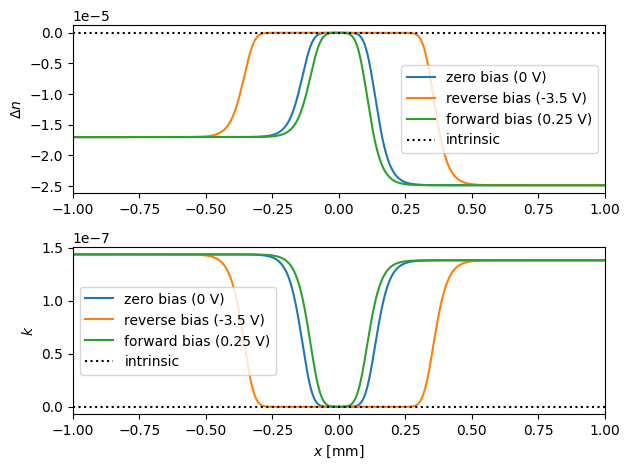

In [ ]:
def effective_eps(n,p):
  # mu is in m^2/(V s) => needs a 1e4 factor since everything else is in cm
  return (eps_opt - (n * q * mu_n*1e4/tau_e * (1 - 1j /w_opt/tau_e) + p * q * mu_p*1e4/tau_h * (1 - 1j /w_opt/tau_h)) / w_opt**2)

def refractiveindex(n,p):
  return np.real(np.sqrt(effective_eps(n,p)/eps_0))

def extinctioncoeff(n,p):
  return np.imag(np.sqrt(effective_eps(n,p)/eps_0))

plt.subplot(2,1,1)
plt.plot(1e4*x, refractiveindex(n_eq, p_eq) - refractiveindex(ni,ni), label="zero bias (0 V)")
plt.plot(1e4*x, refractiveindex(ni * np.exp(solutions[0][1]), ni * np.exp(solutions[0][2])) - refractiveindex(ni,ni), label=f"reverse bias ({V_bias[0]} V)")
plt.plot(1e4*x, refractiveindex(ni * np.exp(solutions[-1][1]), ni * np.exp(solutions[-1][2])) - refractiveindex(ni,ni), label=f"forward bias ({V_bias[-1]} V)")
plt.hlines(0, -1, 1, linestyle=":", color="black", label="intrinsic")

plt.xlim(-1,1)
# plt.xlabel(r"$x$ [mm]")
plt.ylabel(r"$\Delta n$")
plt.legend()

plt.subplot(2,1,2)
plt.plot(1e4*x, extinctioncoeff(n_eq, p_eq), label="zero bias (0 V)")
plt.plot(1e4*x, extinctioncoeff(ni * np.exp(solutions[0][1]), ni * np.exp(solutions[0][2])), label=f"reverse bias ({V_bias[0]} V)")
plt.plot(1e4*x, extinctioncoeff(ni * np.exp(solutions[-1][1]), ni * np.exp(solutions[-1][2])), label=f"forward bias ({V_bias[-1]} V)")
plt.hlines(0, -1, 1, linestyle=":", color="black", label="intrinsic")

plt.xlim(-1,1)
plt.xlabel(r"$x$ [mm]")
plt.ylabel(r"$k$")
plt.legend()

plt.tight_layout()
plt.show()

